In [1]:
import os
import re
import pandas as pd
import tensorflow as tf
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, precision_recall_curve, auc

# Define paths and directories
new_data_dir = '../data/collected/'
model_dir = '/workspace/models'
tables_dir = '/workspace/tables'

batch_size = 16

# Path to the saved model
model_name = 'model_final_20250101_221336'
model_path = os.path.join(model_dir, f'{model_name}.h5')

# Load the trained model
model = tf.keras.models.load_model(model_path, compile=False)

# Define image preprocessing function
def preprocess_image(image_path, target_size=(224, 224)):
    """Loads and preprocesses an image for prediction."""
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize pixel values
    return img_array

# Collect image paths
image_paths = [
    os.path.join(new_data_dir, fname)
    for fname in os.listdir(new_data_dir)
    if re.search(r'\.(jpg|jpeg|png)$', fname, re.IGNORECASE)
]


# Predict categories for the images
pred_prob = []
pred_class = []
for img_path in image_paths:
    img_array = preprocess_image(img_path)
    prediction_prob = model.predict(img_array, verbose=0)
    predicted_class= np.round(prediction_prob)
    pred_prob.append(prediction_prob[0][0])
    pred_class.append(predicted_class[0][0])

# Create a DataFrame to display results
results = pd.DataFrame({
    'image_path': image_paths,
    'pred_prob': pred_prob,
    'pred_class': pred_class
})



# Extract the first digit after the underscore in the file name
results['true_index'] = results['image_path'].apply(
    lambda x: re.search(r'_(\d)', os.path.basename(x)).group(1)
)

# Convert the extracted digit to an integer (optional, if needed)
results['true_index'] = results['true_index'].astype(int)
results

# Label dictionary mapping folder numbers to labels (new dataset)
label_dict = {
    1: "akiec",  # Actinic Keratoses and Intraepithelial Carcinoma / Bowen's Disease
    2: "bcc",    # Basal Cell Carcinoma
    3: "bkl",    # Benign Keratosis-like Lesions
    4: "df",     # Dermatofibroma
    5: "mel",    # Melanoma
    6: "nv",     # Melanocytic Nevi
    7: "vasc"    # Vascular Lesions
}

results['true_lesion'] = results['true_index'].map(label_dict)

# Define malignant and benign classes
benign_labels = ['nv', 'bkl', 'df','vasc']
malignant_labels = ['mel', 'bcc', 'akiec']

results['true_class'] = results['true_lesion'].apply(lambda x: 0 if x in benign_labels else 1)



# Phototype: Extract the fifth digit after the underscore in the file name
results['phototype'] = results['image_path'].apply(
    lambda x: int(re.search(r'_(\d{5})', os.path.basename(x)).group(1)[4])
    if re.search(r'_(\d{5})', os.path.basename(x)) else None
)

# Categorize phototypes into light and dark groups
def categorize_phototype(phototype):
    if phototype in [1, 2, 3]:
        return "light"
    elif phototype in [4, 5, 6]:
        return "dark"
    else:
        return "unknown"  # Handle any unexpected or missing values

# Apply categorization
results['phototype_group'] = results['phototype'].apply(categorize_phototype)
results

2025-01-16 20:46:22.830094: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-16 20:46:23.451328: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2025-01-16 20:46:23.451420: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2025-01-16 20:46:23.451434: W tensorfl

,image_path,pred_prob,pred_class,true_index,true_lesion,true_class,phototype,phototype_group
0,../data/collected/BOSQUE_204231.jpg,0.994924,1.0,2,bcc,1,3,light
1,../data/collected/BOSQUE_203731.jpg,0.898942,1.0,2,bcc,1,3,light
2,../data/collected/BOSQUE_610741.jpg,0.305418,0.0,6,nv,0,4,dark
3,../data/collected/BOSQUE_204932.jpg,0.776949,1.0,2,bcc,1,3,light
4,../data/collected/BOSQUE_114231.jpg,0.999308,1.0,1,akiec,1,3,light
...,...,...,...,...,...,...,...,...
160,../data/collected/BOSQUE_206031.jpg,0.855703,1.0,2,bcc,1,3,light
161,../data/collected/BOSQUE_307051.jpg,0.599442,1.0,3,bkl,0,5,dark
162,../data/collected/BOSQUE_306941.jpg,0.978262,1.0,3,bkl,0,4,dark
163,../data/collected/BOSQUE_409061.jpg,0.497442,0.0,4,df,0,6,dark


In [2]:

# Calculate overall metrics
y_true = results['true_class']
y_pred = results['pred_class']
y_scores = results['pred_prob']

# Overall AUC-ROC
overall_auc_roc = roc_auc_score(y_true, y_scores)

# Overall AUC-PR
precision, recall, _ = precision_recall_curve(y_true, y_scores)
overall_auc_pr = auc(recall, precision)

# Classification report
report = classification_report(y_true, y_pred, target_names=["Benign", "Malignant"])
print("Classification Report (Overall):")
print(report)
print(f"AUC-ROC (Overall): {overall_auc_roc:.4f}")
print(f"AUC-PR (Overall): {overall_auc_pr:.4f}")

# By phototype group
phototype_groups = results['phototype_group'].unique()

group_metrics = []

for group in phototype_groups:
    if group == "unknown":
        continue

    group_data = results[results['phototype_group'] == group]

    if group_data.empty:
        print(f"Warning: No data for phototype group {group}")
        continue

    y_true_group = group_data['true_class']
    y_scores_group = group_data['pred_prob']
    y_pred_group = group_data['pred_class']

    # AUC-ROC
    auc_roc_group = roc_auc_score(y_true_group, y_scores_group)

    # AUC-PR
    precision_group, recall_group, _ = precision_recall_curve(y_true_group, y_scores_group)
    auc_pr_group = auc(recall_group, precision_group)

    # Classification report
    report_group = classification_report(
        y_true_group, y_pred_group, target_names=["Benign", "Malignant"]
    )

    group_metrics.append({
        "Phototype Group": group,
        "AUC-ROC": auc_roc_group,
        "AUC-PR": auc_pr_group,
        "Classification Report": report_group
    })

# Display metrics
for metric in group_metrics:
    print(f"\nPhototype Group: {metric['Phototype Group']}")
    print(f"AUC-ROC: {metric['AUC-ROC']:.4f}")
    print(f"AUC-PR: {metric['AUC-PR']:.4f}")
    print("Classification Report:")
    print(metric['Classification Report'])
    print("-" * 50)

Classification Report (Overall):
              precision    recall  f1-score   support

      Benign       0.81      0.39      0.53        67
   Malignant       0.69      0.94      0.80        98

    accuracy                           0.72       165
   macro avg       0.75      0.66      0.66       165
weighted avg       0.74      0.72      0.69       165

AUC-ROC (Overall): 0.8331
AUC-PR (Overall): 0.8711

Phototype Group: light
AUC-ROC: 0.8228
AUC-PR: 0.9156
Classification Report:
              precision    recall  f1-score   support

      Benign       0.73      0.39      0.51        28
   Malignant       0.82      0.95      0.88        79

    accuracy                           0.80       107
   macro avg       0.77      0.67      0.69       107
weighted avg       0.79      0.80      0.78       107

--------------------------------------------------

Phototype Group: dark
AUC-ROC: 0.8097
AUC-PR: 0.7396
Classification Report:
              precision    recall  f1-score   support

 

In [3]:

# Initialize a list to hold the metric rows
table_rows = []

# Function to calculate sensitivity and specificity
def calculate_sensitivity_specificity(y_true, y_pred):
    TP = sum((y_true == 1) & (y_pred == 1))
    TN = sum((y_true == 0) & (y_pred == 0))
    FP = sum((y_true == 0) & (y_pred == 1))
    FN = sum((y_true == 1) & (y_pred == 0))

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    return sensitivity, specificity

# Overall metrics
y_true = results['true_class']
y_pred = results['pred_class']
y_scores = results['pred_prob']

overall_sensitivity, overall_specificity = calculate_sensitivity_specificity(y_true, y_pred)
overall_accuracy = sum(y_true == y_pred) / len(y_true)
overall_mcc = matthews_corrcoef(y_true, y_pred)
overall_precision_benign = precision_score(y_true, y_pred, pos_label=0)
overall_precision_malignant = precision_score(y_true, y_pred, pos_label=1)
overall_f1_benign = f1_score(y_true, y_pred, pos_label=0)
overall_f1_malignant = f1_score(y_true, y_pred, pos_label=1)
overall_auc_roc = roc_auc_score(y_true, y_scores)
precision, recall, _ = precision_recall_curve(y_true, y_scores)
overall_auc_pr = auc(recall, precision)

n_samples = len(y_true)
table_rows.append({"Metric": "Precision (Benign)", "Value": overall_precision_benign, "Light": None, "Dark": None})
table_rows.append({"Metric": "Precision (Malignant)", "Value": overall_precision_malignant, "Light": None, "Dark": None})
table_rows.append({"Metric": "F1-Score (Benign)", "Value": overall_f1_benign, "Light": None, "Dark": None})
table_rows.append({"Metric": "F1-Score (Malignant)", "Value": overall_f1_malignant, "Light": None, "Dark": None})
table_rows.append({"Metric": "Sensitivity", "Value": overall_sensitivity, "Light": None, "Dark": None})
table_rows.append({"Metric": "Specificity", "Value": overall_specificity, "Light": None, "Dark": None})
table_rows.append({"Metric": "Accuracy", "Value": overall_accuracy, "Light": None, "Dark": None})
table_rows.append({"Metric": "MCC", "Value": overall_mcc, "Light": None, "Dark": None})
table_rows.append({"Metric": "AUC-ROC", "Value": overall_auc_roc, "Light": None, "Dark": None})
table_rows.append({"Metric": "AUC-PR", "Value": overall_auc_pr, "Light": None, "Dark": None})
table_rows.append({"Metric": "n (Samples)", "Value": n_samples, "Light": None, "Dark": None})

# Metrics by phototype group
grouped_metrics = []
for group in phototype_groups:
    group_data = results[results['phototype_group'] == group]
    if group_data.empty:
        continue

    y_true_group = group_data['true_class']
    y_pred_group = group_data['pred_class']
    y_scores_group = group_data['pred_prob']

    sensitivity, specificity = calculate_sensitivity_specificity(y_true_group, y_pred_group)
    accuracy = sum(y_true_group == y_pred_group) / len(y_true_group)
    mcc = matthews_corrcoef(y_true_group, y_pred_group)
    precision_benign = precision_score(y_true_group, y_pred_group, pos_label=0)
    precision_malignant = precision_score(y_true_group, y_pred_group, pos_label=1)
    f1_benign = f1_score(y_true_group, y_pred_group, pos_label=0)
    f1_malignant = f1_score(y_true_group, y_pred_group, pos_label=1)
    auc_roc = roc_auc_score(y_true_group, y_scores_group)
    precision, recall, _ = precision_recall_curve(y_true_group, y_scores_group)
    auc_pr = auc(recall, precision)

    grouped_metrics.append({
        "Phototype Group": group,
        "Precision (Benign)": precision_benign,
        "Precision (Malignant)": precision_malignant,
        "F1-Score (Benign)": f1_benign,
        "F1-Score (Malignant)": f1_malignant,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Accuracy": accuracy,
        "MCC": mcc,
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr,
        "n (Samples)": len(group_data)
    })

# Merge group metrics with overall table
for metric_row in table_rows:
    for group_metric in grouped_metrics:
        if group_metric["Phototype Group"] == "light":
            metric_row["Light"] = group_metric.get(metric_row["Metric"], None)
        elif group_metric["Phototype Group"] == "dark":
            metric_row["Dark"] = group_metric.get(metric_row["Metric"], None)

# Create final table DataFrame
df_metrics = pd.DataFrame(table_rows)

# Save detailed metrics to CSV
detailed_metrics_path = os.path.join(tables_dir, f'detailed_metrics_test_{model_name}.csv')
df_metrics.to_csv(detailed_metrics_path, index=False)
print(f"Detailed metrics saved to {detailed_metrics_path}")
df_metrics

Detailed metrics saved to /workspace/tables/detailed_metrics_test_model_final_20250101_221336.csv


,Metric,Value,Light,Dark
0,Precision (Benign),0.812500,0.733333,0.882353
1,Precision (Malignant),0.691729,0.815217,0.414634
2,F1-Score (Benign),0.525253,0.511628,0.535714
3,F1-Score (Malignant),0.796537,0.877193,0.566667
4,Sensitivity,0.938776,0.949367,0.894737
5,Specificity,0.388060,0.392857,0.384615
6,Accuracy,0.715152,0.803738,0.551724
7,MCC,0.405956,0.433275,0.288035
8,AUC-ROC,0.833080,0.822785,0.809717
9,AUC-PR,0.871150,0.915555,0.739623


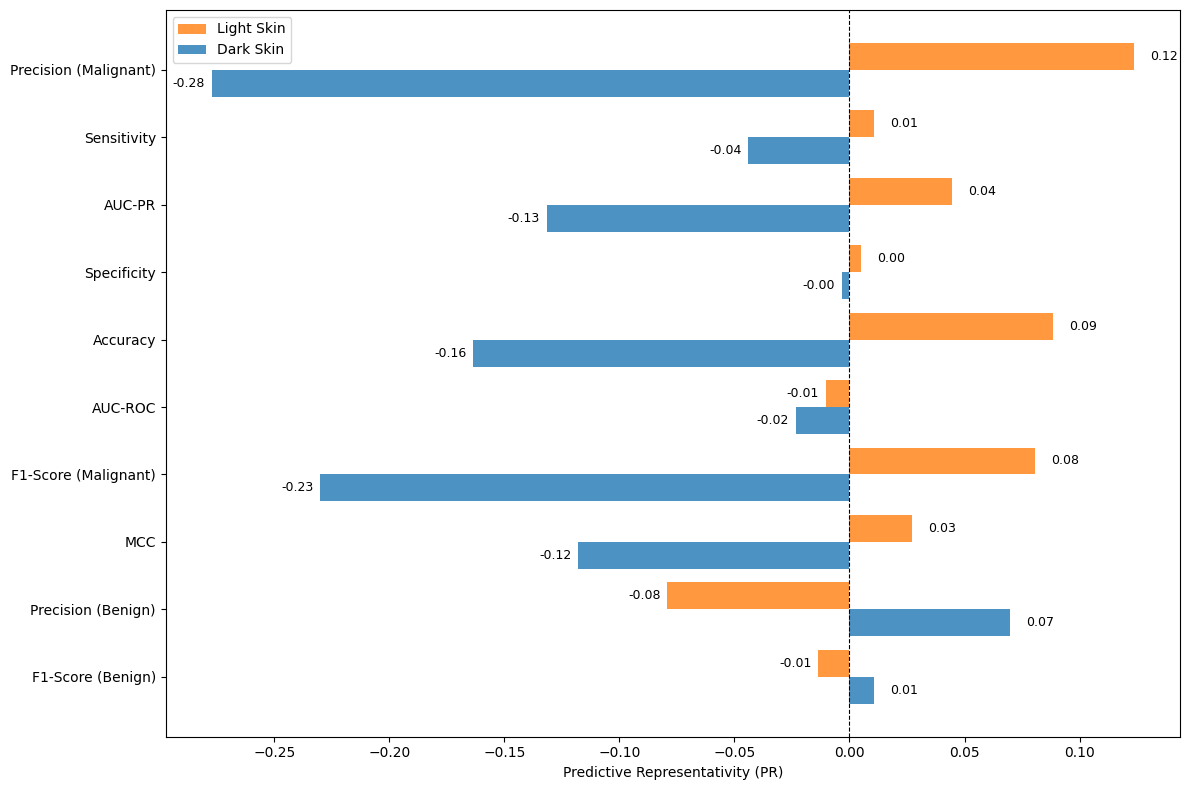

In [4]:

# Create Predictive Representativity (PR) columns
df_metrics["PR (Light)"] = df_metrics["Light"] - df_metrics["Value"]
df_metrics["PR (Dark)"] = df_metrics["Dark"] - df_metrics["Value"]

# Define the contextual importance order
importance_order = [
    "Precision (Malignant)", "Sensitivity", "AUC-PR", "Specificity", 
    "Accuracy", "AUC-ROC", "F1-Score (Malignant)", 
    "MCC", "Precision (Benign)", "F1-Score (Benign)"
]

# Reorder the DataFrame for the plot
df_metrics = df_metrics.set_index("Metric").reindex(importance_order).reset_index()

# Reverse the DataFrame to place the most important metrics at the top of the y-axis
df_metrics = df_metrics[::-1]

# Plotting PR values for Light and Dark Skin
fig, ax = plt.subplots(figsize=(12, 8))

# Width for each bar group
bar_width = 0.4
indices = np.arange(len(df_metrics["Metric"]))

# Bars for Light Skin and Dark Skin
light_bars = ax.barh(indices + bar_width / 2, df_metrics["PR (Light)"], bar_width, label='Light Skin',
                     color= '#ff7f0e', alpha=0.8)
dark_bars = ax.barh(indices - bar_width / 2, df_metrics["PR (Dark)"], bar_width, label='Dark Skin',
                    color='#1f77b4', alpha=0.8)

# Add details to the plot
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel("Predictive Representativity (PR)")
ax.set_title("")
ax.set_yticks(indices)
ax.set_yticklabels(df_metrics["Metric"])
ax.legend()

# Adding value annotations to bars
for bars in [light_bars, dark_bars]:
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.007 if width > 0 else width - 0.017,
                 bar.get_y() + bar.get_height() / 2,
                 f"{width:.2f}", va='center', fontsize=9)

plt.tight_layout()
# Save the plot in the specified directory
output_dir = "/workspace/graphs"
os.makedirs(output_dir, exist_ok=True)  # Ensure the directory exists
plt.savefig(os.path.join(output_dir,f'{model_name}_PR_Values_by_Skin_Tone_Group.png'), dpi=300)

# Show the plot
plt.show()
